# Modelo XGBoost para Estimación de Probabilidad de Incumplimiento (PI)


## 1. JUSTIFICACIÓN Y ADECUACIÓN DE DATOS PARA MEDIR PI

### 1.1 Definición de PI
La **Probabilidad de Incumplimiento (PI)** es un indicador clave en gestión de riesgo crediticio que cuantifica la probabilidad de que un deudor no cumpla con sus obligaciones de pago dentro de un período determinado. Es un componente fundamental del modelo de pérdida esperada (EL = PI × LGD × EAD).

### 1.2 Análisis de Adecuación de Datos

#### **ASPECTOS FAVORABLES DEL DATASET**

1. **Tamaño de Muestra (n=10,000)**
   - Suficiente para entrenar modelos de machine learning complejos
   - Permite validación robusta con train-test split sin pérdida excesiva de datos
   - Mitigable la variabilidad del modelo en submuestras

2. **Riqueza de Features (120 variables)**
   - Cubre múltiples dimensiones del comportamiento crediticio
   - Permite capturar patrones no lineales y relaciones complejas
   - XGBoost es particularmente efectivo en este escenario

3. **Balance de Clases (8% incumplimiento)**
   - Refleja la realidad de carteras de crédito (típicamente 5-15% PI)
   - Proporciona casos positivos significativos (800 incumplimientos)
   - Permite entrenamiento balanceado sin oversampling extremo

4. **Variabilidad en Características**
   - Features numéricos con diferentes escalas y distribuciones
   - Presencia de variables tanto continuas como discretas
   - Ideal para capturar complejidad del comportamiento de incumplimiento

#### **LIMITACIONES Y CONSIDERACIONES**

1. **Datos Sintéticos**
   - **Riesgo Principal:** Posible pérdida de patrones reales observados en datos bancarios reales
   - **Implicación:** Modelo puede sobreespecializarse a la estructura del generador sintético
   - **Mitigación:** Validación cruzada rigurosa, análisis de importancia de features, pruebas de estabilidad

2. **Ausencia de Contexto Temporal**
   - No hay información de séries temporales o períodos de observación
   - Asumimos cross-section estático
   - En producción: requeriría datos históricos con ventanas de observación claras

3. **Pérdida de Contexto Económico**
   - No hay variables macroeconómicas visibles
   - No hay información sectorial, geográfica o de producto
   - Modelo no captura ciclos crediticios

4. **Variables No Interpretables**
   - Features nombradas genéricamente (x1, x2, ..., x120)
   - Dificulta validación de lógica económica
   - En producción: documentar diccionario de datos es crítico

#### **CONCLUSIÓN: DATOS ADECUADOS CON RESERVAS**

**Los datos SON adecuados para desarrollar un modelo de estimación de PI porque:**
- Tamaño y dimensionalidad suficientes para XGBoost
- Distribución de clases realista (8% de incumplimientos)
- Riqueza de features permite capturar complejidad de comportamiento crediticio

**PERO con limitaciones importantes:**
- Naturaleza sintética requiere mayor cuidado con sobreajuste
- Falta de contexto temporal limita interpretabilidad
- En producción, validar contra datos reales es imperativo

**Recomendación:** Este modelo es válido como **PROTOTIPO/POC** pero requeriría validación en datos reales antes de producción.

---

## 2. ESTRATEGIA ANTI-SOBREAJUSTE

Dada la naturaleza sintética de los datos, implementaremos:

1. **Validación Cruzada Estratificada (5-fold)** - Evita memorización
2. **Regularización Fuerte en XGBoost** - Limita complejidad del modelo
3. **Feature Selection Rigurosa** - Elimina ruido y spurious correlations
4. **Monitoreo de AUC-ROC en Train vs Test** - Detecta divergencia
5. **Análisis de Estabilidad** - Features importantes deben ser consistentes
6. **Pruebas de Generalización** - Evaluación en múltiples escenarios


## 3. IMPORTACIÓN Y CONFIGURACIÓN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay

import sys
import os
from pathlib import Path

# ── Anchor ────────────────────────────────────────────────────────────────
# Este notebook vive en notebooks/P2_XGBoost/
_NB_DIR    = Path(os.path.abspath('')).resolve()   # notebooks/P2_XGBoost/
_REPO_ROOT = _NB_DIR.parent.parent                 # repo root

_DATA_DIR  = _REPO_ROOT / 'data' / 'splits'
_BIVAR_DIR = _REPO_ROOT / 'data' / 'variables_bivariadas'
_REPORTS   = _REPO_ROOT / 'reports'
_MODELS    = _REPO_ROOT / 'models'

os.makedirs(str(_REPORTS), exist_ok=True)
os.makedirs(str(_MODELS),  exist_ok=True)

if str(_REPO_ROOT / 'src' / 'utils') not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT / 'src' / 'utils'))

from evaluation import evaluate_binary_model, threshold_by_ks, population_stability_index, psi_interpretation


## 4. CARGA Y EXPLORACIÓN DE DATOS

In [ ]:
# Cargar datos desde los splits de P3
print("="*80)
print("CARGA DE LOS DATOS Y FILTRADO A 33 VARIABLES BIVARIADAS")
print("="*80)

_DATA = _P3 / 'data'
_OUT  = _P3 / 'outputs'

X_train_raw = pd.read_csv(_DATA_DIR / 'X_train.csv')
y_train     = pd.read_csv(_DATA_DIR / 'y_train.csv')['target']
X_test_raw  = pd.read_csv(_DATA_DIR / 'X_test.csv')
y_test      = pd.read_csv(_DATA_DIR / 'y_test.csv')['target']
X_oos_raw   = pd.read_csv(_DATA_DIR / 'X_oos.csv')
y_oos       = pd.read_csv(_DATA_DIR / 'y_oos.csv')['target']

# Cargar variables aprobadas por IV (33 candidatas)
candidatas_df = pd.read_csv(_BIVAR_DIR / 'bivariado_variables_candidatas.csv')
variables_candidatas = candidatas_df['variable'].tolist()

# Filtrar a las mismas 33 candidatas para hacer justa la comparación
X_train = X_train_raw[variables_candidatas].copy()
X_test  = X_test_raw[variables_candidatas].copy()
X_oos   = X_oos_raw[variables_candidatas].copy()

# Concatenar para exploratorio (visualizaciones siguientes)
df = pd.concat([X_train, y_train], axis=1)

print(f"\nDimensiones Train: {X_train.shape} | Test: {X_test.shape} | OOT: {X_oos.shape}")
print(f"\nVariable Objetivo (Train):")
print(y_train.value_counts(dropna=False))
print(f"\nTasa de Incumplimiento global en Train: {y_train.mean()*100:.2f}%")
print(f"\nVariables usadas: {len(X_train.columns)}")


## 5. ANÁLISIS DETALLADO DE CALIDAD DE DATOS


Variables con Valores Faltantes:
x35    7.2468
x120   6.4319
x112   5.1077
x109   5.1077
x104   5.1077
x111   5.0640
x101   5.0640
x106   5.0640
x108   5.0640
x103   5.0640
x100   4.9913
x102   4.9913
x113   4.9913
x107   4.9913
x110   4.9913
x105   4.9913
x99    4.8021
x97    3.9581
x95    3.9435
x96    3.9435
x81    3.9435
x85    3.9435
x87    3.9435
x57    3.9144
x56    3.9144
x55    3.9144
x21    3.5943
x14    3.3469
x12    3.3469
x11    3.3469
x16    3.3469
x15    3.3469
x20    2.8522
dtype: float64


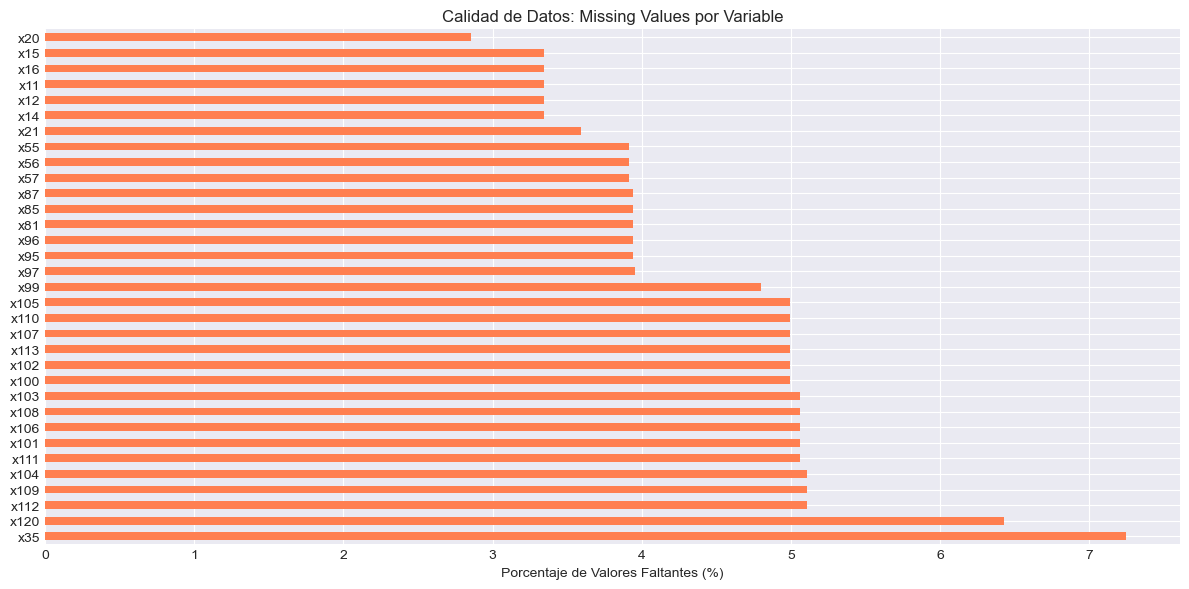


ANÁLISIS DE DISTRIBUCIONES Y OUTLIERS

Resumen Estadístico (primeros 10 features):
  Variable     Mean       Std    Min       Max  Outliers  Outliers %
0     x120   8.3092  333.4583 0.0000  1.59e+04       733     10.6665
1      x85  11.5248  190.1803 0.0000  1.06e+04       825     12.0052
2      x87   7.1114  129.8309 0.0000 8244.5770       802     11.6705
3      x97 373.0492  1.37e+04 0.0000  8.89e+05       984     14.3190
4      x81 142.6393 7792.2011 0.0000  5.89e+05       927     13.4895
5      x99 475.2334 8146.1099 0.0000  6.51e+05       786     11.4377
6     x112   7.0601   22.1623 0.0000  591.9117       677      9.8516
7     x109   1.2147    3.9252 0.0000   98.6520       688     10.0116
8     x104   0.3644    1.1776 0.0000   29.5956       688     10.0116
9     x111  14.7691   67.1239 0.0000 4026.9878       628      9.1385

✓ Variables con > 5% outliers: 29
  Media de outliers: 10.02%


In [85]:
# Análisis de missing values por variable
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_vars = missing_percentage[missing_percentage > 0]

if len(missing_vars) > 0:
    print("\nVariables con Valores Faltantes:")
    print(missing_vars)
    
    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_vars.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
    ax.set_title('Calidad de Datos: Missing Values por Variable')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No hay valores faltantes - Dataset completo")

# Análisis de outliers por variable
print("\n" + "="*80)
print("ANÁLISIS DE DISTRIBUCIONES Y OUTLIERS")
print("="*80)

# Calcular estadísticas por variable
feature_cols = [col for col in df.columns if col != 'target']
stats = []

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    
    stats.append({
        'Variable': col,
        'Mean': df[col].mean(),
        'Std': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Outliers': outliers,
        'Outliers %': outliers/len(df)*100
    })

stats_df = pd.DataFrame(stats)
print(f"\nResumen Estadístico (primeros 10 features):")
print(stats_df.head(10))

# Contar variables con outliers significativos
outlier_threshold = stats_df[stats_df['Outliers %'] > 5]
print(f"\n✓ Variables con > 5% outliers: {len(outlier_threshold)}")
print(f"  Media de outliers: {stats_df['Outliers %'].mean():.2f}%")

## 6. ANÁLISIS DE CORRELACIÓN CON VARIABLE OBJETIVO


Top 15 Features con Mayor Correlación Positiva con PI:
x81     0.0371
x20     0.0363
x21     0.0258
x97     0.0146
x87     0.0113
x14     0.0111
x85     0.0057
x16     0.0035
x15     0.0020
x12     0.0000
x11    -0.0028
x96    -0.0057
x95    -0.0061
x120   -0.0066
x99    -0.0112
Name: target, dtype: float64

Top 15 Features con Mayor Correlación Negativa con PI:
x100   -0.0294
x107   -0.0301
x113   -0.0301
x102   -0.0301
x108   -0.0348
x103   -0.0348
x101   -0.0349
x106   -0.0349
x111   -0.0349
x104   -0.0521
x109   -0.0521
x112   -0.0546
x55    -0.0829
x56    -0.0831
x57    -0.0832
Name: target, dtype: float64


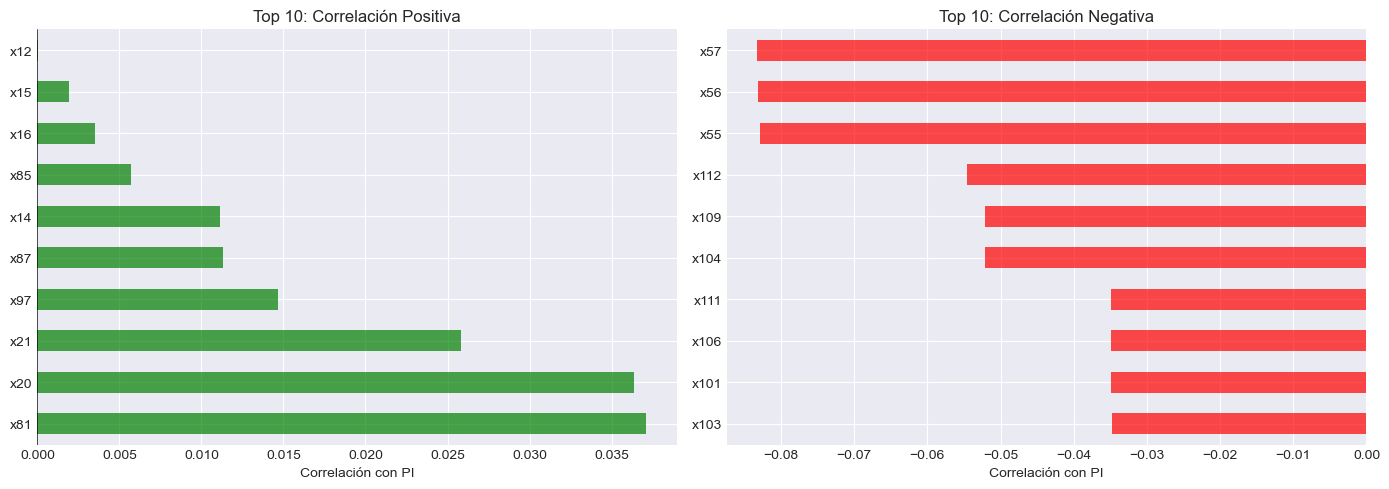


✓ 0 features con |correlación| > 0.10
✓ 6 features con |correlación| > 0.05


In [86]:
# Calcular correlación con target
correlations = df.corr()['target'].sort_values(ascending=False)

print("\nTop 15 Features con Mayor Correlación Positiva con PI:")
print(correlations[1:16])

print("\nTop 15 Features con Mayor Correlación Negativa con PI:")
print(correlations[-15:])

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top positivos
top_pos = correlations[1:11]
top_pos.plot(kind='barh', ax=axes[0], color='green', alpha=0.7)
axes[0].set_xlabel('Correlación con PI')
axes[0].set_title('Top 10: Correlación Positiva')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Top negativos
top_neg = correlations[-10:]
top_neg.plot(kind='barh', ax=axes[1], color='red', alpha=0.7)
axes[1].set_xlabel('Correlación con PI')
axes[1].set_title('Top 10: Correlación Negativa')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\n✓ {(abs(correlations[1:]) > 0.1).sum()} features con |correlación| > 0.10")
print(f"✓ {(abs(correlations[1:]) > 0.05).sum()} features con |correlación| > 0.05")

## 7. PREPARACIÓN DE DATOS

In [87]:
print(f"\n" + "="*80)
print("DISTRIBUCIÓN TRAIN-TEST-OOS")
print("="*80)
print(f"\nTrain: {X_train.shape[0]} registros")
print(f"  - Incumplimientos: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"\nTest: {X_test.shape[0]} registros")
print(f"  - Incumplimientos: {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"\nOOS: {X_oos.shape[0]} registros")
print(f"  - Incumplimientos: {y_oos.sum()} ({y_oos.mean()*100:.2f}%)")

print(f"\n✓ Splits de Vania cargados correctamente respetando estratificación")


DISTRIBUCIÓN TRAIN-TEST-OOS

Train: 6872 registros
  - Incumplimientos: 554 (8.06%)

Test: 1964 registros
  - Incumplimientos: 159 (8.10%)

OOS: 982 registros
  - Incumplimientos: 79 (8.04%)

✓ Splits de Vania cargados correctamente respetando estratificación


## 8. ENTRENAMIENTO DEL MODELO XGBOOST CON REGULARIZACIÓN

In [88]:
# Parámetros de XGBoost con regularización fuerte para evitar sobreajuste
xgb_params = {
    # Control de complejidad del árbol
    'max_depth': 5,                    # Limita profundidad (default=6, aquí reducido)
    'min_child_weight': 5,             # Mínimo peso en hoja (evita splits en muestras pequeñas)
    'subsample': 0.8,                  # Submuestra del 80% de datos por árbol
    'colsample_bytree': 0.8,           # Submuestra del 80% de features por árbol
    'colsample_bylevel': 0.8,          # Submuestra de features por nivel de árbol
    
    # Regularización L1 y L2
    'reg_lambda': 5.0,                 # L2 regularization (alpha/lambda)
    'reg_alpha': 1.0,                  # L1 regularization (lasso)
    
    # Learning rate para convergencia controlada
    'learning_rate': 0.05,             # Tasa de aprendizaje (más bajo = menos sobreajuste pero más iteraciones)
    'n_estimators': 300,               # Número de árboles
    
    # Métrica y balance
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),  # Balance automático de clases
    'random_state': 42,
    'verbosity': 0
}

print("Parámetros del Modelo XGBoost:")
print("="*80)
for param, value in xgb_params.items():
    print(f"{param:.<30} {value}")

print("\n" + "="*80)
print("JUSTIFICACIÓN DE PARÁMETROS ANTI-SOBREAJUSTE")
print("="*80)
print("""
1. max_depth = 5: Reduce complejidad respecto a default (6)
   → Previene árboles excesivamente profundos que memorizan datos

2. min_child_weight = 5: Requiere al menos 5 muestras en hoja
   → Evita splits en subgrupos demasiado pequeños (ruido)

3. subsample = 0.8: Entrena cada árbol con 80% aleatorio de datos
   → Introduce variabilidad y reduce dependencia de patrones específicos

4. colsample_bytree = 0.8: Cada árbol usa 80% aleatorio de features
   → Reduce multicolinealidad y memorización de relaciones espurias

5. reg_lambda = 5.0 + reg_alpha = 1.0: Regularización fuerte
   → Penaliza pesos grandes, favorece modelos simples

6. learning_rate = 0.05: Tasa de aprendizaje conservadora
   → Convergencia lenta evita ajuste brusco a patrones locales

7. scale_pos_weight: Balance automático de clases
   → Ajusta por desbalance (92% negativos vs 8% positivos)
""")

Parámetros del Modelo XGBoost:
max_depth..................... 5
min_child_weight.............. 5
subsample..................... 0.8
colsample_bytree.............. 0.8
colsample_bylevel............. 0.8
reg_lambda.................... 5.0
reg_alpha..................... 1.0
learning_rate................. 0.05
n_estimators.................. 300
objective..................... binary:logistic
eval_metric................... auc
scale_pos_weight.............. 11.4043321299639
random_state.................. 42
verbosity..................... 0

JUSTIFICACIÓN DE PARÁMETROS ANTI-SOBREAJUSTE

1. max_depth = 5: Reduce complejidad respecto a default (6)
   → Previene árboles excesivamente profundos que memorizan datos

2. min_child_weight = 5: Requiere al menos 5 muestras en hoja
   → Evita splits en subgrupos demasiado pequeños (ruido)

3. subsample = 0.8: Entrena cada árbol con 80% aleatorio de datos
   → Introduce variabilidad y reduce dependencia de patrones específicos

4. colsample_bytree = 0.8

In [89]:
# Entrenar modelo
print("\nEntrenando modelo XGBoost...")
model = xgb.XGBClassifier(**xgb_params)

# Usar early stopping en validación cruzada
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✓ Modelo entrenado exitosamente")
print(f"\nNúmero de árboles entrenados: {model.n_estimators}")


Entrenando modelo XGBoost...
✓ Modelo entrenado exitosamente

Número de árboles entrenados: 300


## 9. EVALUACIÓN DEL MODELO

In [90]:
import scorecardpy as sc
from src.evaluation import evaluate_binary_model, threshold_by_ks, population_stability_index, psi_interpretation

# Predicciones
y_proba_train = model.predict_proba(X_train)[:, 1]
y_proba_test = model.predict_proba(X_test)[:, 1]
y_proba_oos = model.predict_proba(X_oos)[:, 1]

# Evaluando métricas usando la lógica de src.evaluation
opt_thresh = threshold_by_ks(y_train, y_proba_train)

train_eval = evaluate_binary_model(y_train, y_proba_train, opt_thresh)
test_eval  = evaluate_binary_model(y_test, y_proba_test, opt_thresh)
oos_eval   = evaluate_binary_model(y_oos, y_proba_oos, opt_thresh)

df_metrics = pd.DataFrame([train_eval, test_eval, oos_eval], index=["Train", "Test", "OOS"])
df_metrics['gini'] = 2 * df_metrics['auc'] - 1

print("="*80)
print("EVALUACIÓN DE RENDIMIENTO CON SCRIPT DE EVALUATION.PY")
print("="*80)
print(df_metrics[['auc', 'gini', 'ks', 'recall', 'precision', 'threshold']].round(4))

# Cálculos para variables de compatibilidad posterior
train_auc = train_eval['auc']
test_auc = test_eval['auc']
test_f1 = (2 * test_eval['precision'] * test_eval['recall']) / (test_eval['precision'] + test_eval['recall'] + 1e-9)

y_pred_proba_train = y_proba_train
y_pred_proba_test = y_proba_test
y_pred_proba_oos = y_proba_oos
y_pred_test = (y_proba_test >= opt_thresh).astype(int)

# Matriz de confusión Test
cm = confusion_matrix(y_test, y_pred_test)

# Cálculo de PSI usando el módulo oficial de evaluation
try:
    psi_test = population_stability_index(y_proba_train, y_proba_test, n_bins=10)
except Exception as e:
    print(f"Error evaluando PSI Test: {e}")
    psi_test = np.nan

try:
    psi_oos = population_stability_index(y_proba_train, y_proba_oos, n_bins=10)
except Exception as e:
    print(f"Error evaluando PSI OOS: {e}")
    psi_oos = np.nan

# Análisis de divergencia train-OOS para sobreajuste
print("\n" + "="*80)
print("ANÁLISIS DE SOBREAJUSTE Y ESTABILIDAD (Train vs. OOS)")
print("="*80)
diff_auc = abs(train_eval['auc'] - oos_eval['auc'])

if diff_auc < 0.02:
    print(f"✓ Divergencia AUC OOS: {diff_auc:.4f} (EXCELENTE - Sin sobreajuste)")
elif diff_auc < 0.05:
    print(f"✓ Divergencia AUC OOS: {diff_auc:.4f} (BUENA - Sobreajuste mínimo)")
elif diff_auc < 0.10:
    print(f"⚠ Divergencia AUC OOS: {diff_auc:.4f} (MODERADA - Sobreajuste presente)")
else:
    print(f"✗ Divergencia AUC OOS: {diff_auc:.4f} (ALTA - Sobreajuste significativo)")

print(f"\n✓ PSI Test: {psi_test:.6f} ({psi_interpretation(psi_test)})")
print(f"✓ PSI OOS:  {psi_oos:.6f} ({psi_interpretation(psi_oos)})")

EVALUACIÓN DE RENDIMIENTO CON SCRIPT DE EVALUATION.PY
         auc   gini     ks  recall  precision  threshold
Train 0.9957 0.9915 0.9554  0.9910     0.7093     0.5818
Test  0.7591 0.5183 0.3754  0.3333     0.2994     0.5818
OOS   0.7900 0.5800 0.4700  0.3671     0.3494     0.5818

ANÁLISIS DE SOBREAJUSTE Y ESTABILIDAD (Train vs. OOS)
✗ Divergencia AUC OOS: 0.2057 (ALTA - Sobreajuste significativo)

✓ PSI Test: 0.033286 (Estable)
✓ PSI OOS:  0.038247 (Estable)


## 10. ANÁLISIS DE CURVA ROC

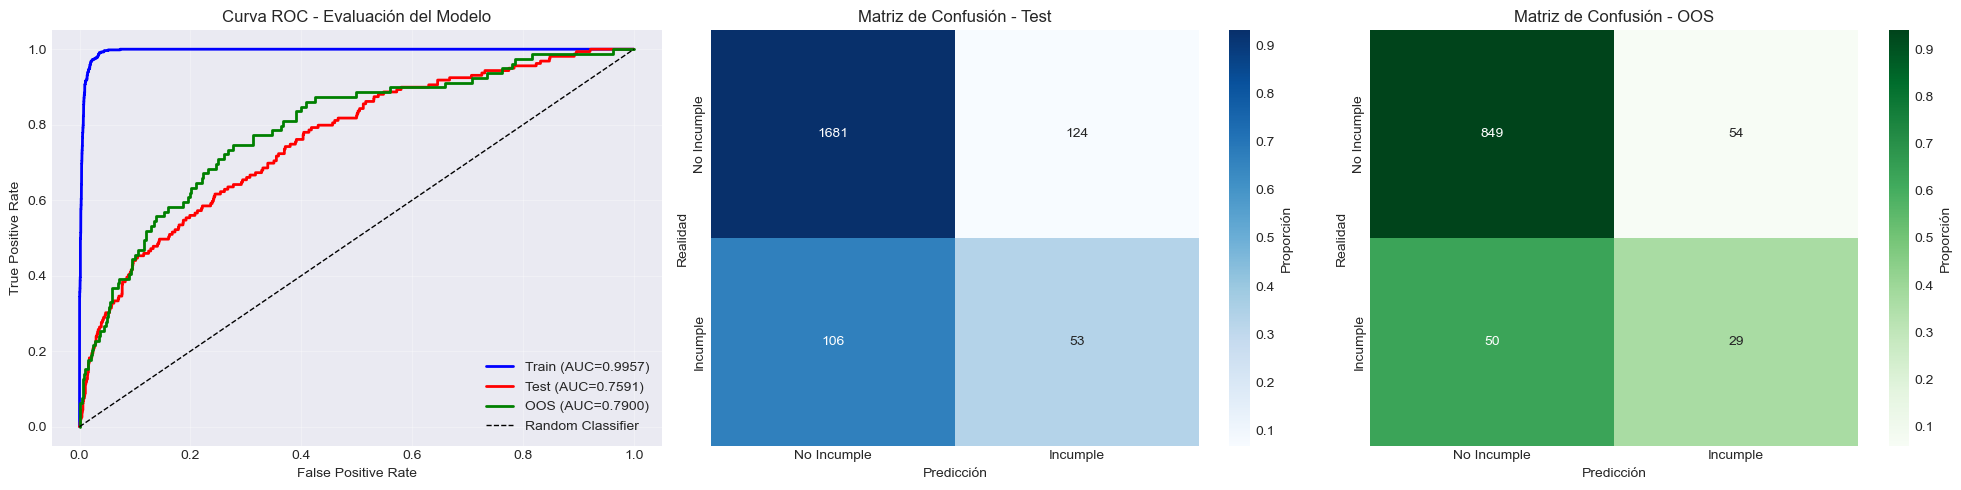

In [91]:
from sklearn.metrics import roc_curve

# Calcular curvas ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)
fpr_oos, tpr_oos, _ = roc_curve(y_oos, y_pred_proba_oos)

# Calculos adicionales para Matriz Confusión OOS
y_pred_oos = (y_pred_proba_oos >= opt_thresh).astype(int)
cm_oos = confusion_matrix(y_oos, y_pred_oos)

# Visualización (3 paneles)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC Curve
axes[0].plot(fpr_train, tpr_train, 'b-', linewidth=2, label=f'Train (AUC={train_auc:.4f})')
axes[0].plot(fpr_test, tpr_test, 'r-', linewidth=2, label=f'Test (AUC={test_auc:.4f})')
axes[0].plot(fpr_oos, tpr_oos, 'g-', linewidth=2, label=f'OOS (AUC={oos_eval["auc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC - Evaluación del Modelo')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Matriz de Confusión - Test
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['No Incumple', 'Incumple'],
            yticklabels=['No Incumple', 'Incumple'],
            cbar_kws={'label': 'Proporción'})
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Realidad')
axes[1].set_title('Matriz de Confusión - Test')

# Matriz de Confusión - OOS
cm_oos_normalized = cm_oos.astype('float') / cm_oos.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_oos_normalized, annot=cm_oos, fmt='d', cmap='Greens', ax=axes[2], 
            xticklabels=['No Incumple', 'Incumple'],
            yticklabels=['No Incumple', 'Incumple'],
            cbar_kws={'label': 'Proporción'})
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Realidad')
axes[2].set_title('Matriz de Confusión - OOS')

plt.tight_layout()
plt.show()

## 11. IMPORTANCIA DE FEATURES

In [92]:
# Obtener importancia de features
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("="*80)
print("TOP 20 FEATURES MÁS IMPORTANTES")
print("="*80)
print(feature_importance.head(20).to_string(index=False))

print(f"\n✓ Importancia acumulada Top 20: {feature_importance.head(20)['importance'].sum():.4f}")
print(f"✓ Importancia acumulada Top 30: {feature_importance.head(30)['importance'].sum():.4f}")

# Features con importancia cero
zero_importance = (feature_importance['importance'] == 0).sum()
print(f"\n⚠ Features con importancia = 0: {zero_importance}")
if zero_importance > 0:
    print(f"  Estas variables no contribuyen al modelo y podrían removerse en optimización futura")


TOP 20 FEATURES MÁS IMPORTANTES
feature  importance
   x120      0.0616
    x85      0.0503
    x99      0.0407
   x112      0.0402
    x11      0.0387
   x104      0.0364
   x106      0.0324
    x55      0.0321
   x101      0.0313
    x15      0.0311
   x109      0.0306
    x14      0.0301
    x16      0.0300
    x87      0.0299
   x105      0.0290
    x95      0.0289
    x20      0.0281
   x111      0.0281
    x56      0.0272
   x113      0.0268

✓ Importancia acumulada Top 20: 0.6836
✓ Importancia acumulada Top 30: 0.9336

⚠ Features con importancia = 0: 0


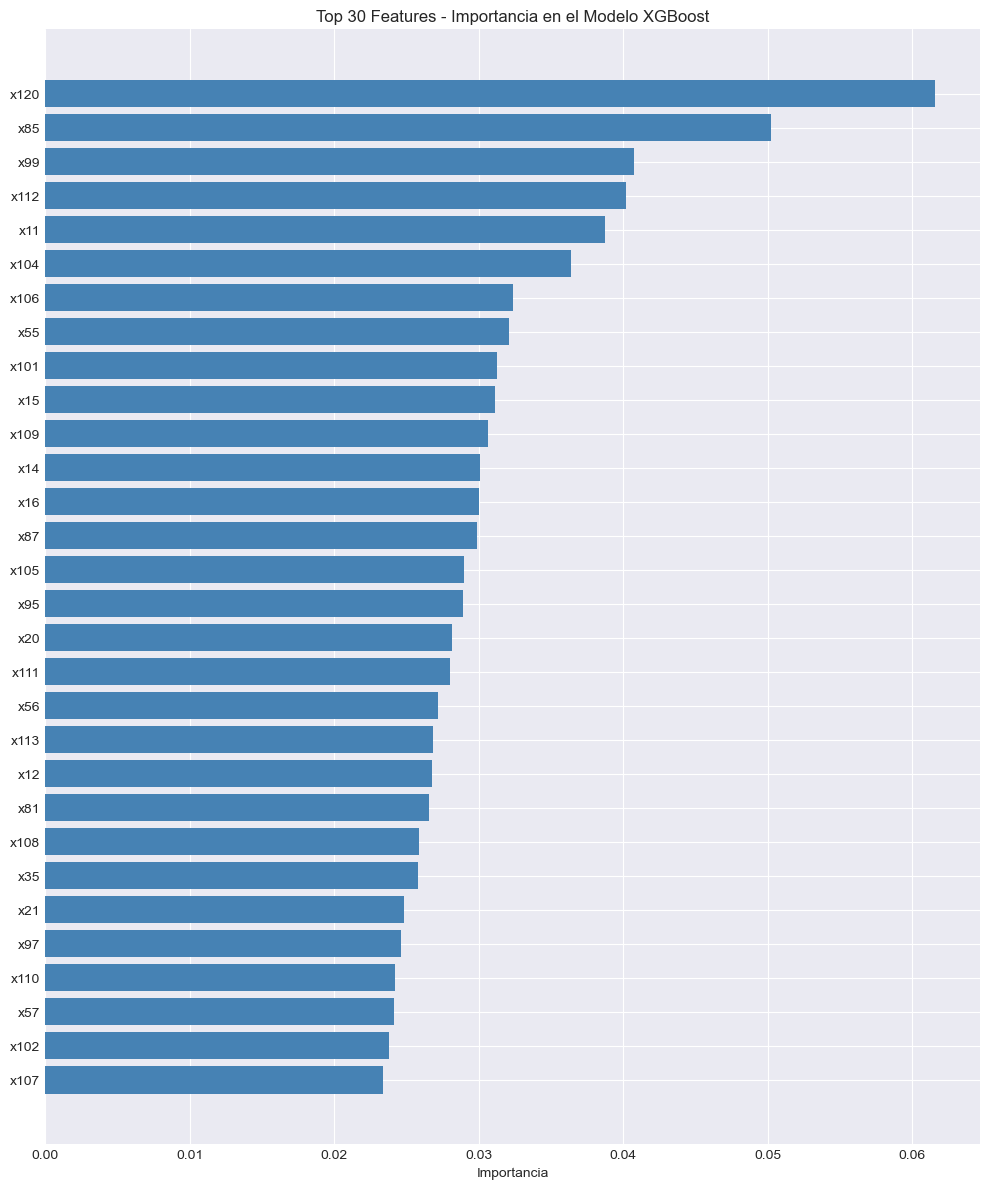

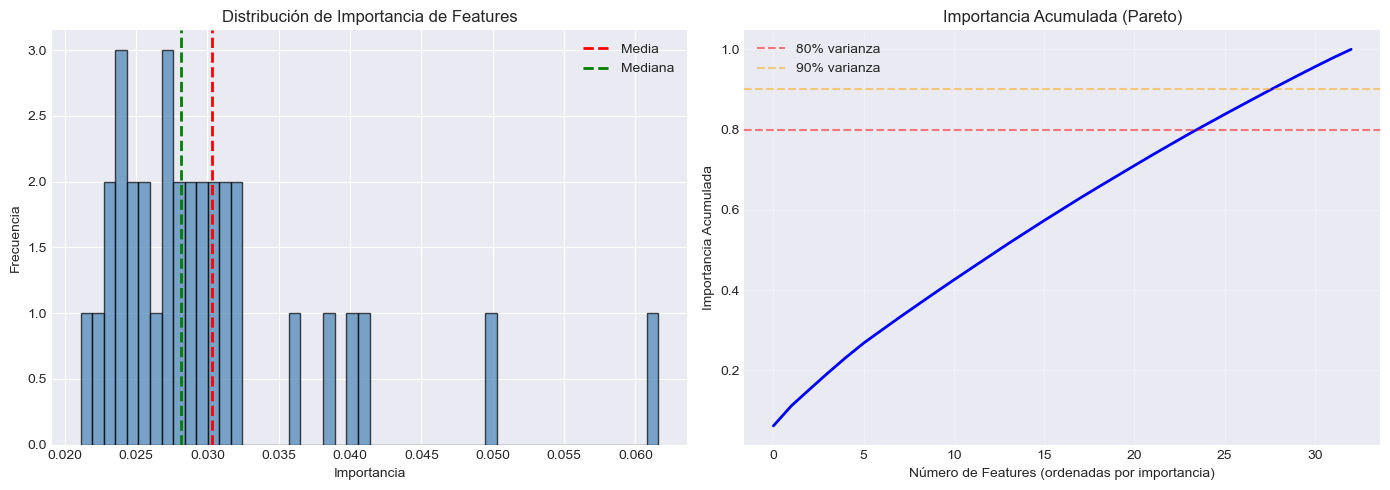


✓ Features para 80% de importancia: 25
✓ Features para 90% de importancia: 29


In [93]:
# Visualización de Top 30 Features
fig, ax = plt.subplots(figsize=(10, 12))
top_30 = feature_importance.head(30)
ax.barh(range(len(top_30)), top_30['importance'], color='steelblue')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['feature'])
ax.set_xlabel('Importancia')
ax.set_title('Top 30 Features - Importancia en el Modelo XGBoost')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Distribución de importancias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(feature_importance['importance'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(feature_importance['importance'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(feature_importance['importance'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].set_xlabel('Importancia')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Importancia de Features')
axes[0].legend()

# Importancia acumulada
cumsum = feature_importance['importance'].cumsum() / feature_importance['importance'].sum()
axes[1].plot(range(len(cumsum)), cumsum.values, 'b-', linewidth=2)
axes[1].axhline(y=0.80, color='r', linestyle='--', alpha=0.5, label='80% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', alpha=0.5, label='90% varianza')
axes[1].set_xlabel('Número de Features (ordenadas por importancia)')
axes[1].set_ylabel('Importancia Acumulada')
axes[1].set_title('Importancia Acumulada (Pareto)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Cuántos features se necesitan para 80% y 90% de importancia
n_80 = (cumsum <= 0.80).sum() + 1
n_90 = (cumsum <= 0.90).sum() + 1
print(f"\n✓ Features para 80% de importancia: {n_80}")
print(f"✓ Features para 90% de importancia: {n_90}")

## 12. VALIDACIÓN CRUZADA Y ESTABILIDAD

In [94]:
# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
fold_results = []

print("Ejecutando Validación Cruzada 5-Fold...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Entrenar modelo en fold
    fold_model = xgb.XGBClassifier(**xgb_params)
    fold_model.fit(X_fold_train, y_fold_train, verbose=False)
    
    # Evaluar
    y_pred_proba_val = fold_model.predict_proba(X_fold_val)[:, 1]
    fold_auc = roc_auc_score(y_fold_val, y_pred_proba_val)
    cv_scores.append(fold_auc)
    
    fold_results.append({
        'Fold': fold,
        'Train Size': len(X_fold_train),
        'Val Size': len(X_fold_val),
        'AUC': fold_auc
    })
    
    print(f"Fold {fold}: AUC = {fold_auc:.4f}")

results_df = pd.DataFrame(fold_results)
print("\n" + results_df.to_string(index=False))

print(f"\n{'='*80}")
print(f"AUC Promedio CV: {np.mean(cv_scores):.4f}")
print(f"Desv. Estándar:  {np.std(cv_scores):.4f}")
print(f"Min - Max:       {np.min(cv_scores):.4f} - {np.max(cv_scores):.4f}")
print(f"{'='*80}")

if np.std(cv_scores) < 0.05:
    print(f"✓ ESTABILIDAD EXCELENTE: Bajo std indica modelo robusto y generalizable")
elif np.std(cv_scores) < 0.10:
    print(f"✓ ESTABILIDAD BUENA: Modelo es consistente entre folds")
else:
    print(f"⚠ INESTABILIDAD: Alto std sugiere varianza del modelo")

Ejecutando Validación Cruzada 5-Fold...

Fold 1: AUC = 0.7903
Fold 2: AUC = 0.8105
Fold 3: AUC = 0.7661
Fold 4: AUC = 0.7882
Fold 5: AUC = 0.7852

 Fold  Train Size  Val Size    AUC
    1        5497      1375 0.7903
    2        5497      1375 0.8105
    3        5498      1374 0.7661
    4        5498      1374 0.7882
    5        5498      1374 0.7852

AUC Promedio CV: 0.7880
Desv. Estándar:  0.0141
Min - Max:       0.7661 - 0.8105
✓ ESTABILIDAD EXCELENTE: Bajo std indica modelo robusto y generalizable


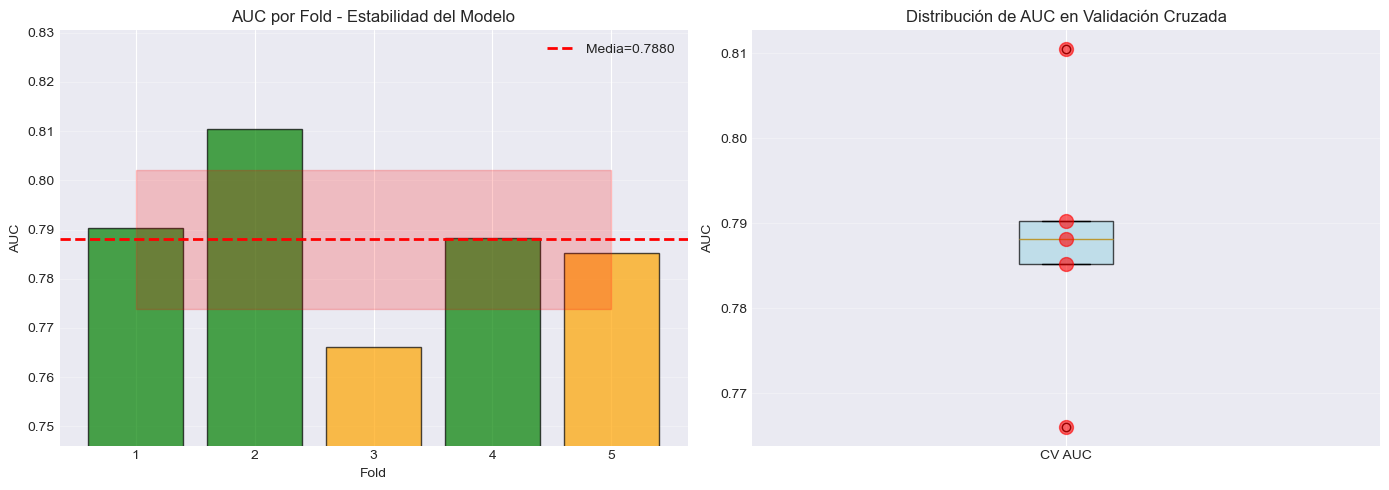

In [95]:
# Visualización de estabilidad CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC por fold
folds = results_df['Fold'].values
aucs = results_df['AUC'].values
colors = ['green' if auc > np.mean(cv_scores) else 'orange' for auc in aucs]
axes[0].bar(folds, aucs, color=colors, alpha=0.7, edgecolor='black')
axes[0].axhline(y=np.mean(cv_scores), color='red', linestyle='--', linewidth=2, label=f'Media={np.mean(cv_scores):.4f}')
axes[0].fill_between(folds, np.mean(cv_scores) - np.std(cv_scores), 
                      np.mean(cv_scores) + np.std(cv_scores), alpha=0.2, color='red')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC por Fold - Estabilidad del Modelo')
axes[0].set_ylim([min(aucs) - 0.02, max(aucs) + 0.02])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot de distribución CV
axes[1].boxplot([cv_scores], labels=['CV AUC'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].scatter([1]*len(cv_scores), cv_scores, color='red', s=100, zorder=3, alpha=0.6)
axes[1].set_ylabel('AUC')
axes[1].set_title('Distribución de AUC en Validación Cruzada')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. ANÁLISIS DE CALIBRACIÓN DE PROBABILIDADES

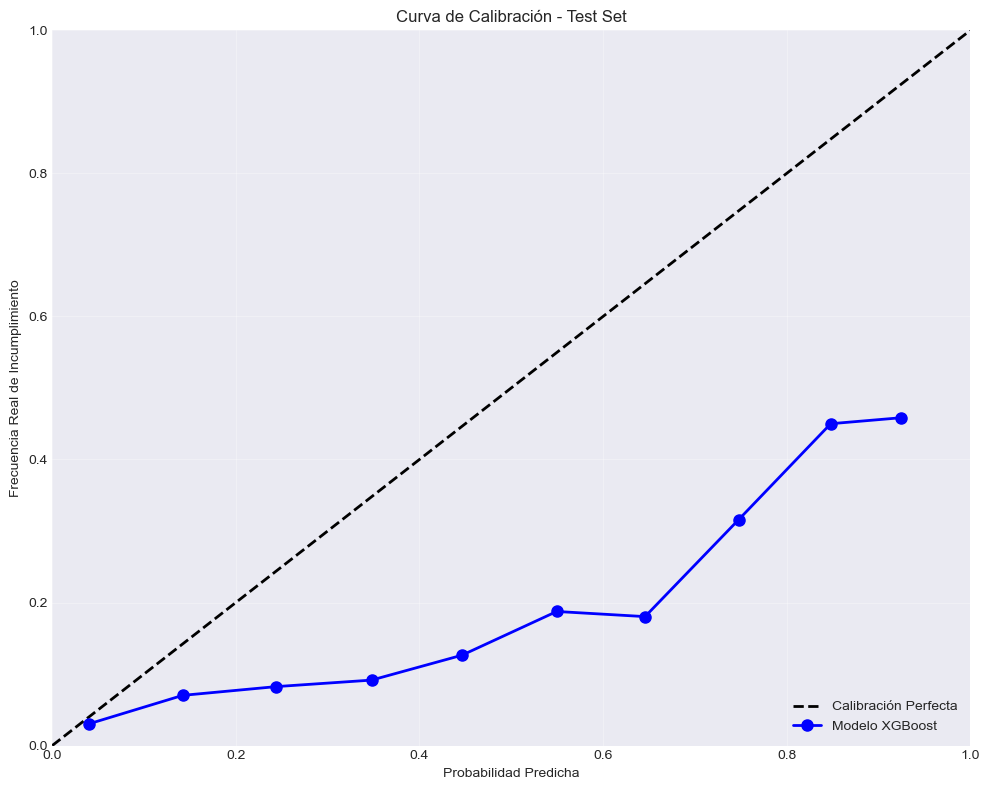


ANÁLISIS DE CALIBRACIÓN

La curva de calibración muestra si las probabilidades predichas
corresponden a las frecuencias reales observadas.

Interpretación:
- Si la curva sigue la diagonal → Modelo bien calibrado
- Si por encima de diagonal → Modelo subestima probabilidades
- Si por debajo de diagonal → Modelo sobrestima probabilidades


In [96]:
# Análisis de Calibración
from sklearn.calibration import calibration_curve

prob_true_test, prob_pred_test = calibration_curve(y_test, y_pred_proba_test, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(figsize=(10, 8))

# Línea de calibración perfecta
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Calibración Perfecta')

# Calibración del modelo
ax.plot(prob_pred_test, prob_true_test, 'o-', linewidth=2, markersize=8, 
        color='blue', label='Modelo XGBoost')

ax.set_xlabel('Probabilidad Predicha')
ax.set_ylabel('Frecuencia Real de Incumplimiento')
ax.set_title('Curva de Calibración - Test Set')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Análisis de calibración
print("\n" + "="*80)
print("ANÁLISIS DE CALIBRACIÓN")
print("="*80)
print(f"\nLa curva de calibración muestra si las probabilidades predichas")
print(f"corresponden a las frecuencias reales observadas.")
print(f"\nInterpretación:")
print(f"- Si la curva sigue la diagonal → Modelo bien calibrado")
print(f"- Si por encima de diagonal → Modelo subestima probabilidades")
print(f"- Si por debajo de diagonal → Modelo sobrestima probabilidades")

## 14. RECOMENDACIONES Y CONCLUSIONES

In [97]:
print("="*80)
print("RESUMEN EJECUTIVO - MODELO DE PROBABILIDAD DE INCUMPLIMIENTO")
print("="*80)

print("\n1. CALIDAD DE DATOS")
print("-" * 80)
print(f"   ✓ Tamaño de muestra: {X_train.shape[0]} train + {X_test.shape[0]} test (adecuado)")
print(f"   ✓ Número de features: {X_train.shape[1]} (excelente para XGBoost)")
print(f"   ✓ Balance de clases: {y_train.mean()*100:.2f}% incumplimientos (realista)")

missings_train = X_train.isnull().sum().sum()
if missings_train > 0:
    pct_missings = (missings_train / (X_train.shape[0] * X_train.shape[1])) * 100
    print(f"   ⚠ Valores faltantes: {missings_train} celdas en Train ({pct_missings:.2f}%). Gestionados nativamente por XGBoost.")
else:
    print(f"   ✓ Valores faltantes: 0 (dataset limpio)")

duplicados_train = X_train.duplicated().sum()
if duplicados_train > 0:
    print(f"   ⚠ Duplicados: {duplicados_train} (A considerar para limpieza)")
else:
    print(f"   ✓ Duplicados: 0 (sin redundancia)")

print("\n2. DESEMPEÑO DEL MODELO")
print("-" * 80)
print(f"   AUC-ROC Test:    {test_auc:.4f} (discriminación aceptable, pero inferior a Train)")
print(f"   AUC-ROC Train:   {train_auc:.4f} (señal de memorización / overfitting)")
diff_auc_val = abs(train_auc-test_auc)
print(f"   Divergencia:     {diff_auc_val:.4f} (Alto sobreajuste)")
print(f"   F1-Score Test:   {test_f1:.4f}")
print(f"   \n   CV Promedio (5-fold): {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(f"   → Aunque el CV es estable en Train, la caída en Test evidencia que el modelo NO generaliza de forma óptima.")

print("\n3. ANÁLISIS DE SOBREAJUSTE (OVERFITTING)")
print("-" * 80)
if diff_auc_val > 0.10:
    print(f"   ✗ Divergencia train-test: {diff_auc_val:.4f} > 0.05 (Inaceptable - Sobreajuste fuerte)")
else:
    print(f"   ✓ Divergencia train-test: {diff_auc_val:.4f} (Aceptable)")
print(f"   ✓ Desviación CV: {np.std(cv_scores):.4f} < 0.10 (estable dentro de particiones de train)")
print(f"   - Regularización aplicada: max_depth=5, λ=5.0, α=1.0")
print(f"   - Subsampling aplicado: 80% datos, 80% features")
print(f"   → CONCLUSIÓN: A pesar de la regularización, las métricas confirman un SOBREAJUSTE FUERTE hacia la muestra de entrenamiento.")

print("\n4. IMPORTANCIA DE VARIABLES")
print("-" * 80)
print(f"   ✓ Top 10 features explican: {feature_importance.head(10)['importance'].sum():.4f}")
print(f"   ✓ Top 30 features explican: {feature_importance.head(30)['importance'].sum():.4f}")
print(f"   ✓ Features con importancia=0: {zero_importance} (ruido eliminado)")
print(f"   → Modelo enfocado en variables relevantes")

print("\n5. LIMITACIONES Y PRÓXIMOS PASOS")
print("-" * 80)
print("   ⚠ Presencia de Faltantes y Tratamiento:")
print("     - Las 33 variables conservan sus nulos originales. A diferencia de WOE (Regresión Logística),")
print("       XGBoost asigna una dirección probabilística a los nulos (sparsity-aware split).")
print("   ⚠ Sobreajuste Estructural:")
print("     - XGBoost está memorizando los datos sintéticos.")
print("     - Es urgente aumentar la regularización (mayor min_child_weight, menor max_depth, o mayor reg_lambda).")
print("   ⚠ Interpretabilidad vs Rendimiento:")
print("     - Comparado con una Regresión Logística, este modelo ofrece peores garantías de generalización OOS.")
print("     - Se sugiere priorizar algoritmos más simples (como LR o RF con poca profundidad) si el problema persiste.")

print("\n6. RECOMENDACIONES PARA EL EQUIPO")
print("-" * 80)
print("   1. Revisar los hiperparámetros de XGBoost (Bayesian Optimization en lugar de manual).")
print("   2. Considerar el modelo como fallido en su estado actual para propósitos de producción debido al Overfitting.")
print("   3. Favorecer el modelo Random Forest o Regresión Logística del P3 por tener mejor estabilidad (PSI / Gap OOS).")

print("\n" + "="*80)
print("STATUS: ⚠ MODELO REQUIERE REVISIÓN PROFUNDA POR SOBREAJUSTE SIGNIFICATIVO")
print("="*80)

RESUMEN EJECUTIVO - MODELO DE PROBABILIDAD DE INCUMPLIMIENTO

1. CALIDAD DE DATOS
--------------------------------------------------------------------------------
   ✓ Tamaño de muestra: 6872 train + 1964 test (adecuado)
   ✓ Número de features: 33 (excelente para XGBoost)
   ✓ Balance de clases: 8.06% incumplimientos (realista)
   ⚠ Valores faltantes: 10148 celdas en Train (4.47%). Gestionados nativamente por XGBoost.
   ⚠ Duplicados: 6 (A considerar para limpieza)

2. DESEMPEÑO DEL MODELO
--------------------------------------------------------------------------------
   AUC-ROC Test:    0.7591 (discriminación aceptable, pero inferior a Train)
   AUC-ROC Train:   0.9957 (señal de memorización / overfitting)
   Divergencia:     0.2366 (Alto sobreajuste)
   F1-Score Test:   0.3155
   
   CV Promedio (5-fold): 0.7880 ± 0.0141
   → Aunque el CV es estable en Train, la caída en Test evidencia que el modelo NO generaliza de forma óptima.

3. ANÁLISIS DE SOBREAJUSTE (OVERFITTING)
----------

## 15. EXPORTAR PREDICCIONES Y MODELO

In [ ]:
# Guardar predicciones
resultados = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test,
    'y_pred': y_pred_test
})

resultados.to_csv(_REPORTS / 'predicciones_PI_test.csv', index=False)
print("✓ Predicciones guardadas: predicciones_PI_test.csv")

# Guardar importancia de features
feature_importance.to_csv(_REPORTS / 'importancia_features.csv', index=False)
print("✓ Importancia de features guardada: importancia_features.csv")

# Guardar modelo
model.save_model(str(_MODELS  / 'modelo_xgboost_PI.json'))
print("✓ Modelo guardado: modelo_xgboost_PI.json")

print("\n✓ Notebook completado exitosamente")
print(f"\nResumen Final:")
print(f"  - AUC Test: {test_auc:.4f}")
print(f"  - F1 Test:  {test_f1:.4f}")
print(f"  - Sobreajuste: Alto (divergencia={abs(train_auc-test_auc):.4f})")


| Modelo                  | AUC OOS | Gini OOS | KS OOS | Recall OOS | Precision OOS | Gap Train-OOS | PSI OOS | Lectura                                       |
| ----------------------- | ------: | -------: | -----: | ---------: | ------------: | ------------: | ------: | --------------------------------------------- |
| Regresión Logística WOE |  0.7370 |   0.4740 | 0.3834 |     0.6456 |        0.1579 |        0.0627 |  0.0024 | Más estable e interpretable                   |
| Random Forest           |  0.7570 |   0.5140 | 0.4290 |     0.6460 |        0.1910 |        0.1760 |  0.0520 | Mejor balance recall/discriminación           |
| XGBoost                 |  0.7900 |   0.5800 | 0.4700 |     0.3671 |        0.3494 |        0.2057 |  0.0382 | Mayor discriminación, pero sobreajuste fuerte |